<a href="https://colab.research.google.com/github/de-fernandez/CPE-313-CPE32S3/blob/main/Group10_TimeSeriesReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pmdarima -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.1 MB/s eta 0:00:00


a


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose


In [ ]:

df = pd.read_csv("/content/drive/MyDrive/CPE313/A5.1/Dataset/train.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

ts = df.groupby("Order Date")["Sales"].sum().sort_index()
ts = ts.asfreq("D").ffill()

ts.head()

,Sales
Order Date,
2015-01-03,16.448
2015-01-04,288.060
2015-01-05,19.536
2015-01-06,4407.100
2015-01-07,87.158


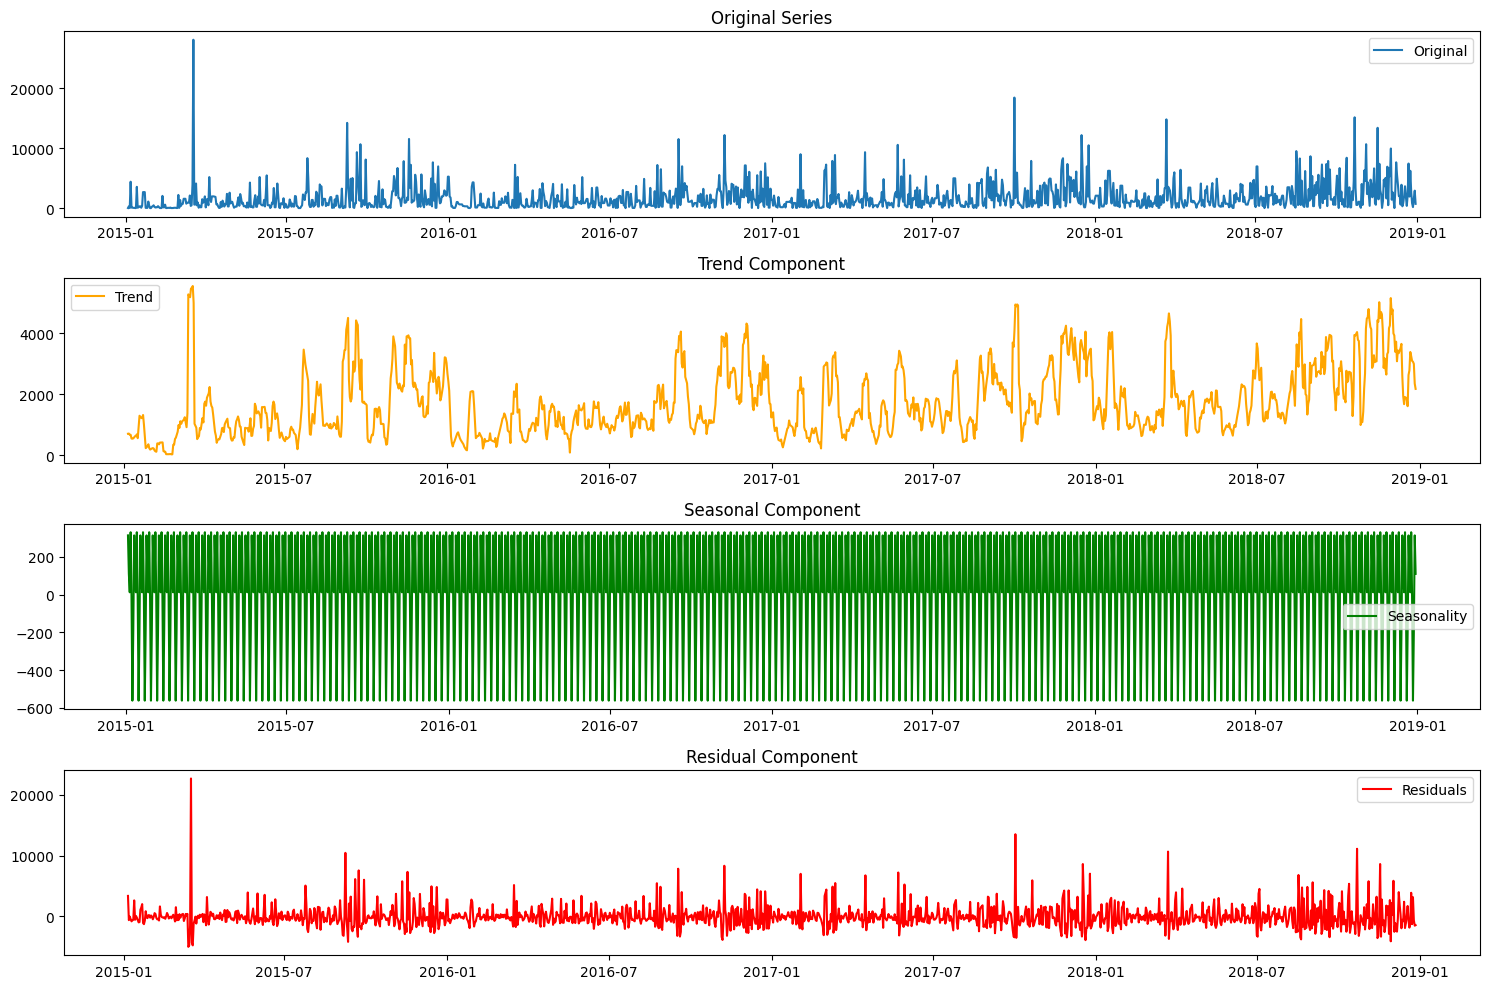

In [ ]:
decomposition = seasonal_decompose(ts, model="additive", period=7)  # weekly seasonality

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid
plt.figure(figsize=(15,10))

plt.subplot(4,1,1)
plt.plot(ts, label="Original")
plt.title("Original Series")
plt.legend()

plt.subplot(4,1,2)
plt.plot(trend, label="Trend", color="orange")
plt.title("Trend Component")
plt.legend()

plt.subplot(4,1,3)
plt.plot(seasonal, label="Seasonality", color="green")
plt.title("Seasonal Component")
plt.legend()

plt.subplot(4,1,4)
plt.plot(residual, label="Residuals", color="red")
plt.title("Residual Component")
plt.legend()

plt.tight_layout()
plt.show()

A1


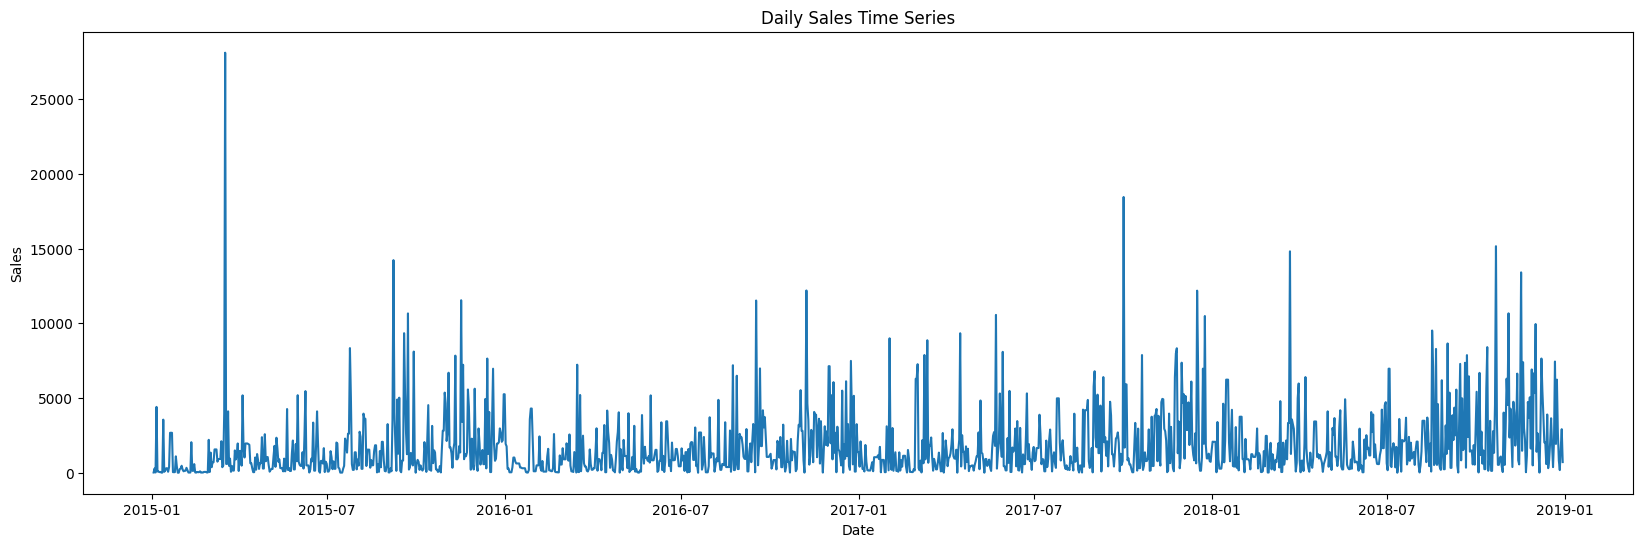

In [ ]:
plt.figure(figsize=(20,6))
plt.plot(ts)
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

A2

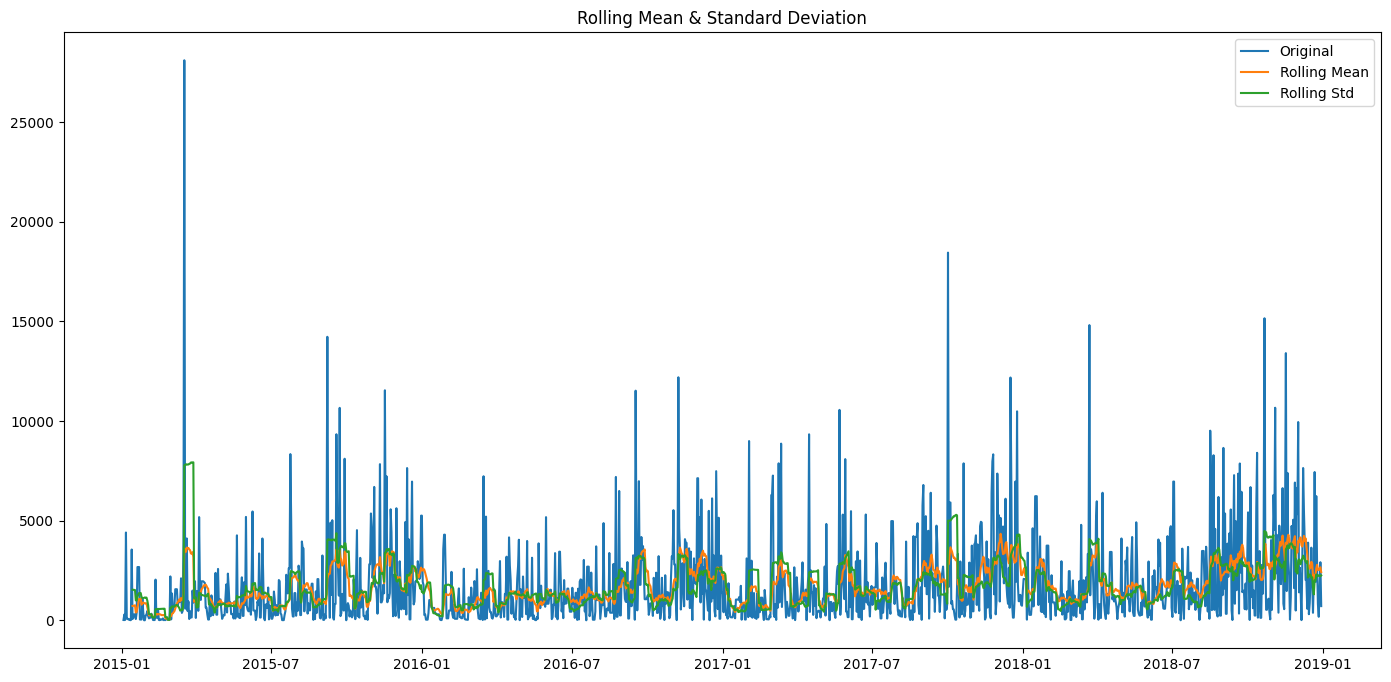

In [ ]:
rolling_mean = ts.rolling(12).mean()
rolling_std = ts.rolling(12).std()

plt.figure(figsize=(17,8))
plt.plot(ts, label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.title("Rolling Mean & Standard Deviation")
plt.show()

A3

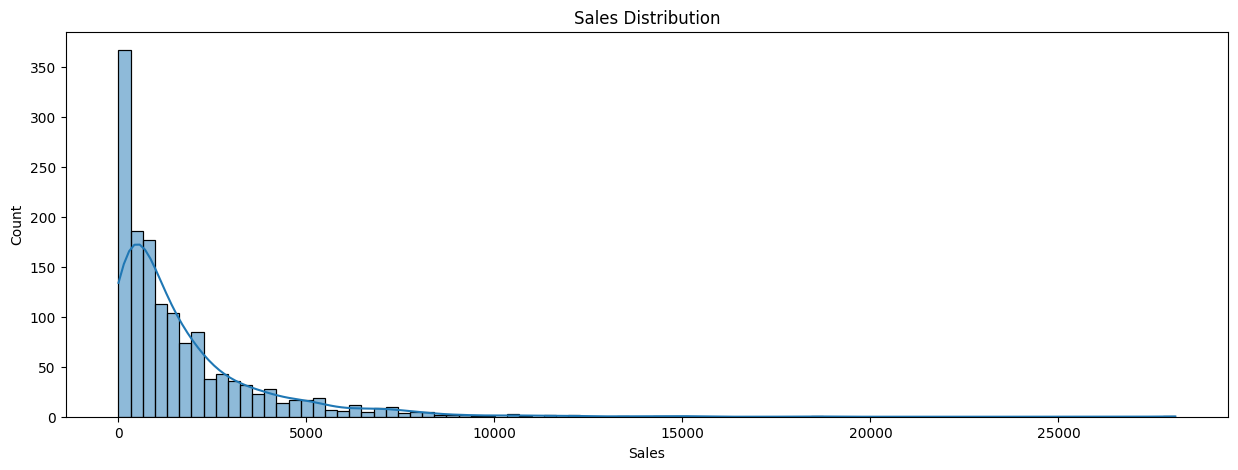

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(ts, kde=True)
plt.title("Sales Distribution")
plt.show()


A4

In [ ]:
result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -6.251366350804214
p-value: 4.4457704265947836e-08
Critical Values:
1%: -3.4348929812602784
5%: -2.863546418485167
10%: -2.5678382024888378


A5

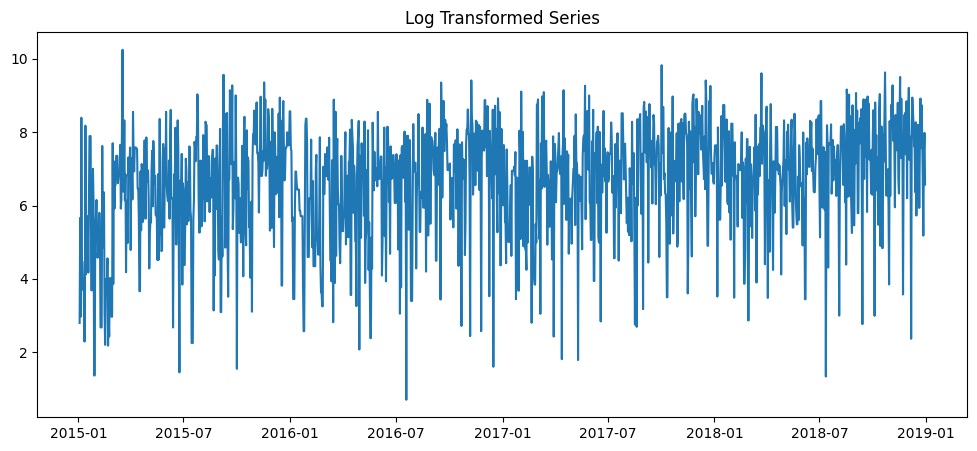

In [ ]:
ts_log = np.log(ts)

plt.figure(figsize=(12,5))
plt.plot(ts_log)
plt.title("Log Transformed Series")
plt.show()

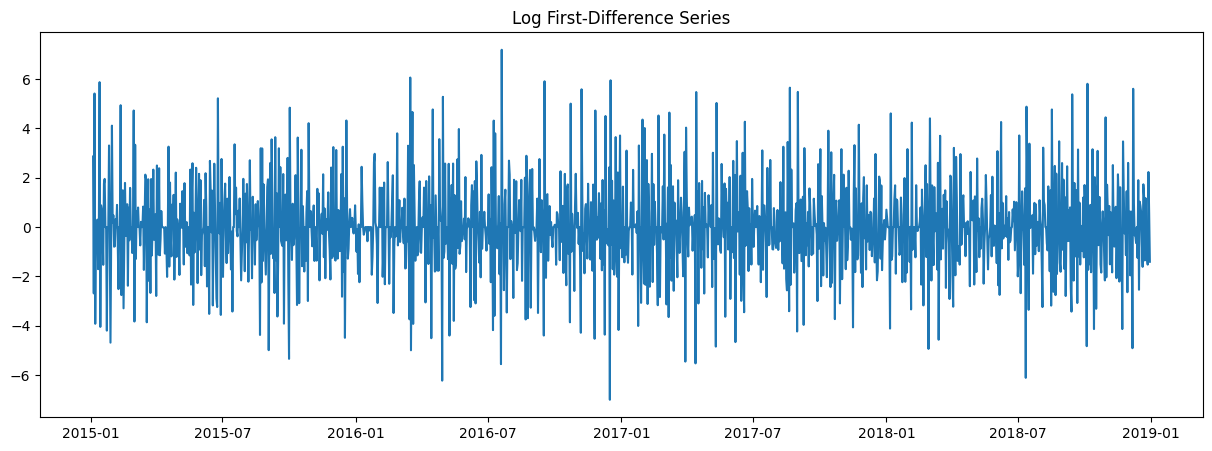

In [ ]:
ts_log = np.log(ts)
ts_diff = ts_log.diff().dropna()

plt.figure(figsize=(15,5))
plt.plot(ts_diff)
plt.title("Log First-Difference Series")
plt.show()

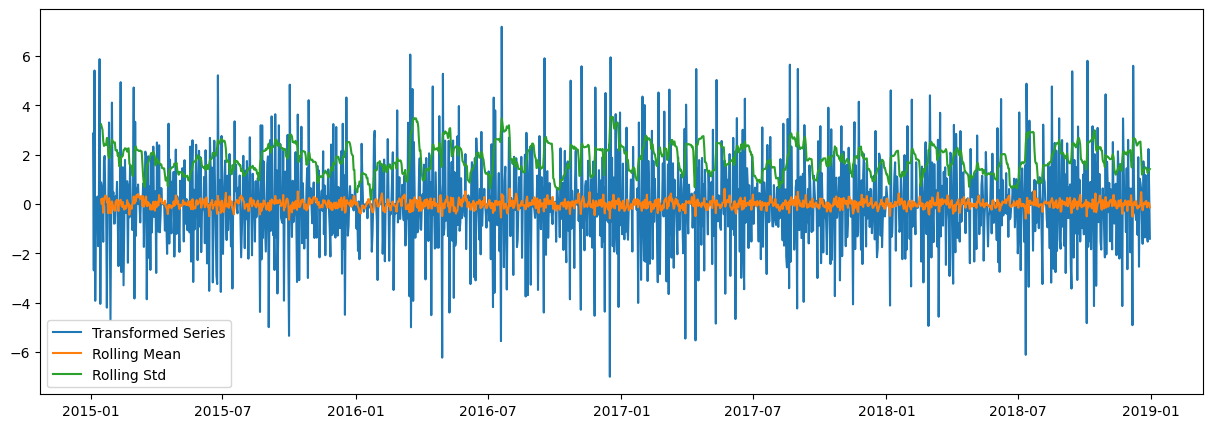

In [ ]:
rolling_mean2 = ts_diff.rolling(12).mean()
rolling_std2 = ts_diff.rolling(12).std()

plt.figure(figsize=(15,5))
plt.plot(ts_diff, label="Transformed Series")
plt.plot(rolling_mean2, label="Rolling Mean")
plt.plot(rolling_std2, label="Rolling Std")
plt.legend()
plt.show()

In [ ]:
result2 = adfuller(ts_diff)
print("ADF Statistic:", result2[0])
print("p-value:", result2[1])
for key, value in result2[4].items():
    print(f"{key}: {value}")

ADF Statistic: -12.449144584669337
p-value: 3.6079985141450997e-23
1%: -3.434918371231736
5%: -2.8635576234668982
10%: -2.5678441693558898


End of A5

Checking

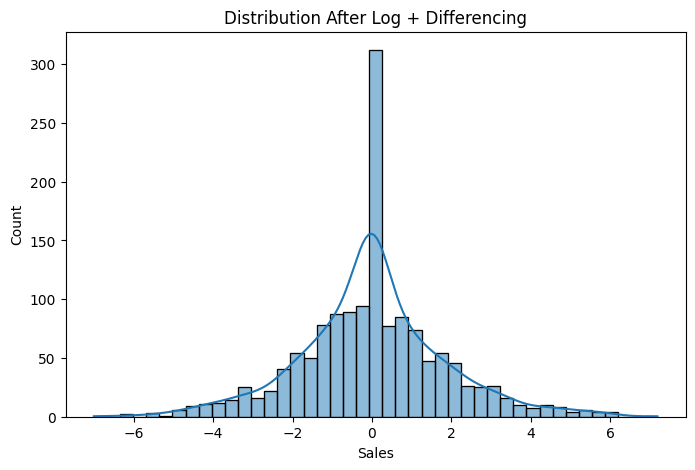

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(ts_diff, kde=True)
plt.title("Distribution After Log + Differencing")
plt.show()

# Part 2

1.Hold-out split – last 20 % of observations → test set.

In [ ]:
split = int(len(ts_diff) * 0.8)
train = ts_diff[:split]
test = ts_diff[split:]

print(f"Train length: {len(train)}, Test length: {len(test)}")

Train length: 1165, Test length: 292


In [ ]:
test_orig = ts.iloc[split:]  # WARNING: ts includes the first point needed for cumulative sum
last_log_value = np.log(ts.iloc[split-1])  # last known log value before test


Model 1: Smoothing (Simple Moving Average with Grid Search)

In [ ]:
windows = [3,5,7,10,12,15,20]
best_window = None
best_mse = float("inf")

for w in windows:
    preds = []
    for i in range(len(test)):
        history = pd.concat([train, test[:i]])
        preds.append(history.tail(w).mean())
    mse = mean_squared_error(test, preds)
    if mse < best_mse:
        best_mse = mse
        best_window = w

print("Best SMA window:", best_window)



# Forecast SMA
sma_preds = []
for i in range(len(test)):
    history = pd.concat([train, test[:i]])
    sma_preds.append(history.tail(best_window).mean())
sma_preds = np.array(sma_preds)

Best SMA window: 15


In [ ]:
# Inverse log-diff to original scale
sma_forecast_orig = np.exp(np.cumsum(sma_preds) + last_log_value)

Model 2: Autoregression (AR-p) – choose p via PACF or AIC minimisation.

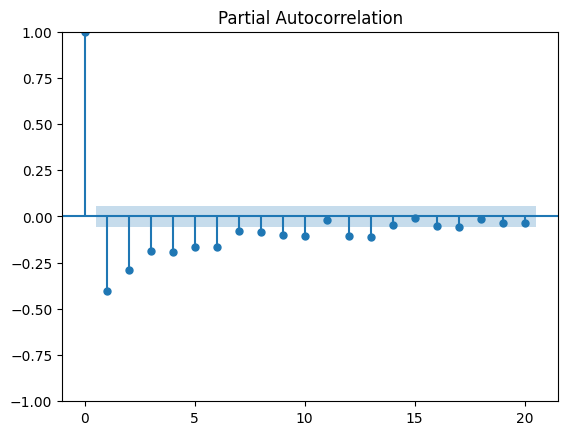

In [ ]:
plot_pacf(train, lags=20)
plt.show()

p = 1
ar_model = AutoReg(train, lags=p).fit()
ar_preds = ar_model.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)
ar_forecast_orig = np.exp(np.cumsum(ar_preds) + last_log_value)


In [ ]:
ar_forecast_orig = np.exp(np.cumsum(ar_preds) + last_log_value)

Model 3: ARIMA(p,d,q) – use auto_arima (or manual grid search) on the stationary series.

In [ ]:
auto_model = auto_arima(train,
                        start_p=0, start_q=0,
                        max_p=10, max_q=10,
                        seasonal=False,
                        d=0,
                        trace=False,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print("Best ARIMA order:", auto_model.order)
arima_preds = auto_model.predict(n_periods=len(test))

Best ARIMA order: (1, 0, 1)


In [ ]:
# Inverse log-diff to original scale
arima_forecast_orig = np.exp(np.cumsum(arima_preds) + last_log_value)


post

In [ ]:
test_orig_aligned = ts.iloc[split:split+len(test)]

In [ ]:
print(len(test_orig_aligned), len(sma_forecast_orig), len(ar_forecast_orig), len(arima_forecast_orig))

292 292 292 292


In [ ]:
results_orig = pd.DataFrame({
    "Model": ["SMA", "AR", "ARIMA (auto)"],
    "MSE": [
        mean_squared_error(test_orig_aligned, sma_forecast_orig),
        mean_squared_error(test_orig_aligned, ar_forecast_orig),
        mean_squared_error(test_orig_aligned, arima_forecast_orig)
    ]
})

print(results_orig)

          Model           MSE
0           SMA  7.920346e+06
1            AR  6.802600e+06
2  ARIMA (auto)  8.688878e+06


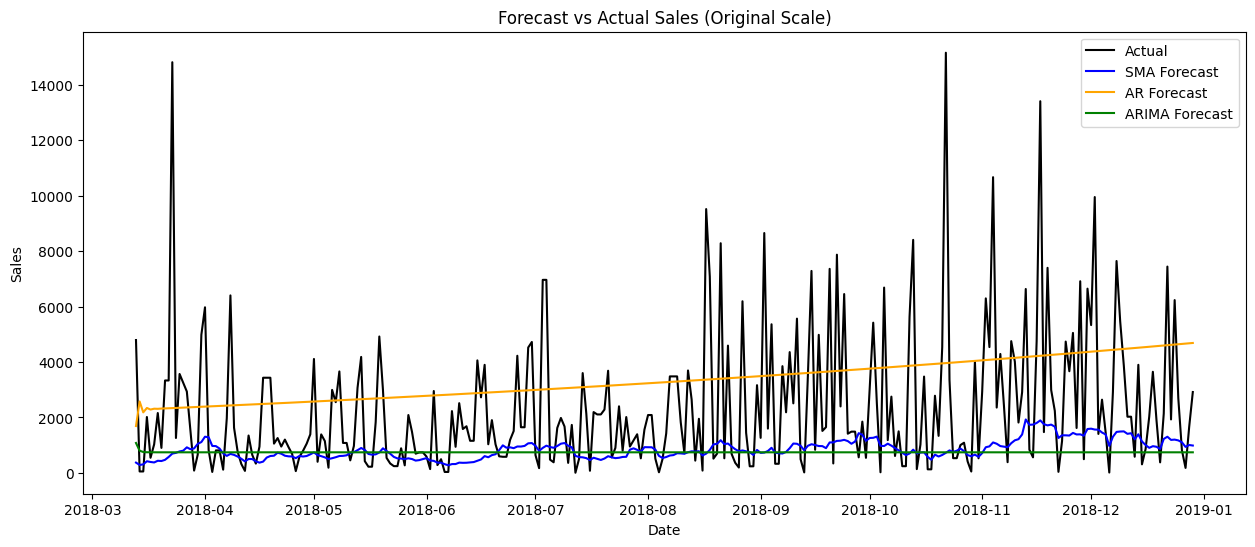

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(test_orig_aligned.index, test_orig_aligned, label="Actual", color="black")
plt.plot(test_orig_aligned.index, sma_forecast_orig, label="SMA Forecast", color="blue")
plt.plot(test_orig_aligned.index, ar_forecast_orig, label="AR Forecast", color="orange")
plt.plot(test_orig_aligned.index, arima_forecast_orig, label="ARIMA Forecast", color="green")
plt.title("Forecast vs Actual Sales (Original Scale)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Part 3

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

In [ ]:
split_idx = int(len(ts) * 0.8)
train_orig = ts.iloc[:split_idx]
test_orig = ts.iloc[split_idx:]

SES

In [ ]:
ses_model = SimpleExpSmoothing(train_orig).fit()
ses_forecast = ses_model.forecast(len(test_orig))

DES

In [ ]:
holt_model = Holt(train_orig).fit()
holt_forecast = holt_model.forecast(len(test_orig))

TES

In [ ]:
tes_model = ExponentialSmoothing(train_orig,
                                 trend="add",
                                 seasonal="add",
                                 seasonal_periods=7).fit()
tes_forecast = tes_model.forecast(len(test_orig))

Compute

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/y_true)) * 100

exp_smoothing_results = pd.DataFrame({
    "Model": ["SES", "Holt", "Holt-Winters"],
    "MSE": [
        mean_squared_error(test_orig, ses_forecast),
        mean_squared_error(test_orig, holt_forecast),
        mean_squared_error(test_orig, tes_forecast)
    ],
    "MAPE (%)": [
        mean_absolute_percentage_error(test_orig, ses_forecast),
        mean_absolute_percentage_error(test_orig, holt_forecast),
        mean_absolute_percentage_error(test_orig, tes_forecast)
    ]
})

print(exp_smoothing_results)

          Model           MSE    MAPE (%)
0           SES  7.077149e+06  455.927542
1          Holt  1.069607e+07  224.878973
2  Holt-Winters  6.615511e+06  351.440027


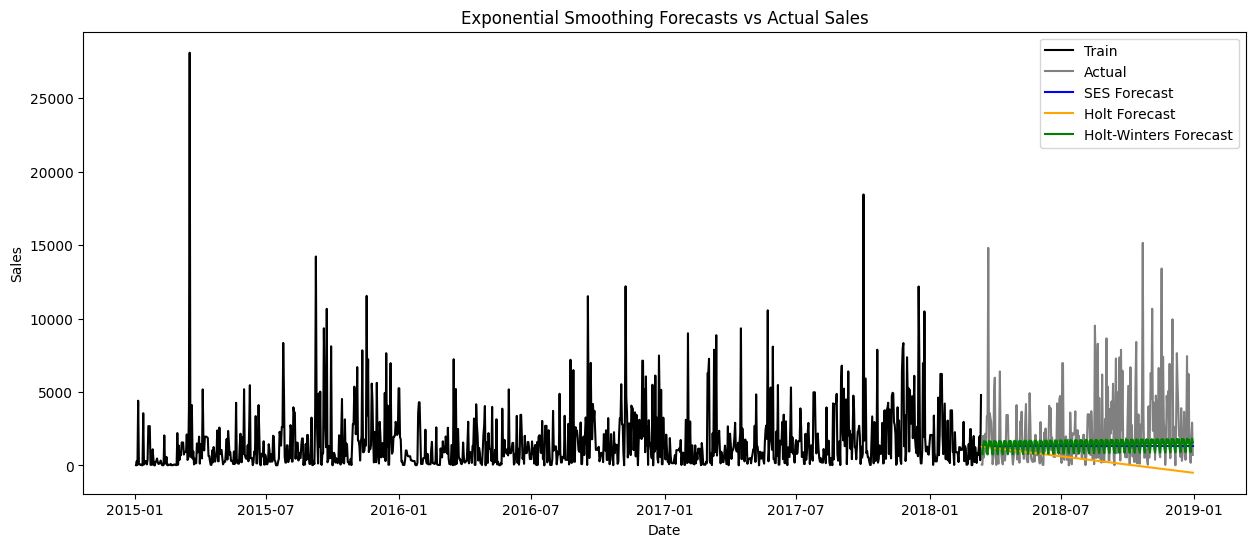

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(train_orig.index, train_orig, label="Train", color="black")
plt.plot(test_orig.index, test_orig, label="Actual", color="gray")
plt.plot(test_orig.index, ses_forecast, label="SES Forecast", color="blue")
plt.plot(test_orig.index, holt_forecast, label="Holt Forecast", color="orange")
plt.plot(test_orig.index, tes_forecast, label="Holt-Winters Forecast", color="green")
plt.title("Exponential Smoothing Forecasts vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Part 4

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
train_stationary = ts_diff[:split_idx]
test_stationary = ts_diff[split_idx:]

ACF/PACF Plots

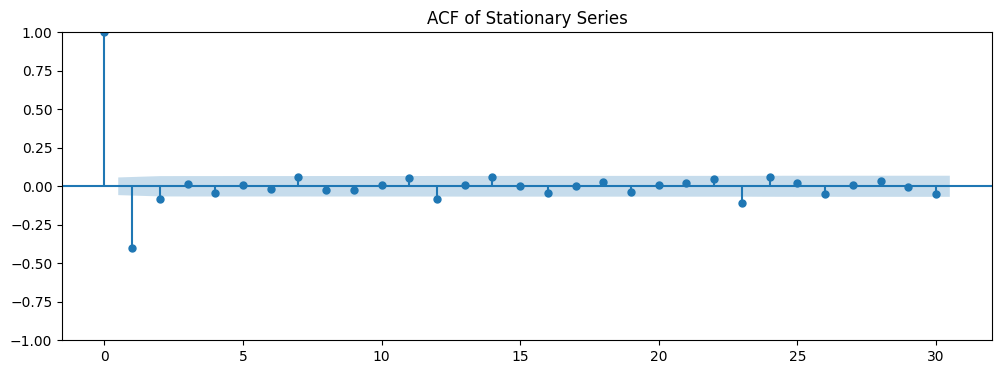

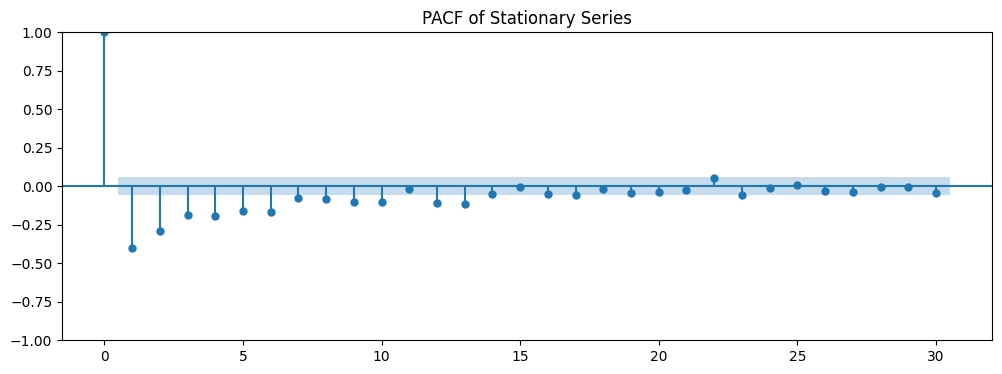

In [ ]:
plt.figure(figsize=(12,4))
plot_acf(train_stationary, lags=30, ax=plt.gca())
plt.title("ACF of Stationary Series")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(train_stationary, lags=30, ax=plt.gca())
plt.title("PACF of Stationary Series")
plt.show()

AR(p) Model

In [ ]:
p = 1
ar_model = AutoReg(train_stationary, lags=p).fit()
ar_pred_stationary = ar_model.predict(start=len(train_stationary),
                                      end=len(train_stationary)+len(test_stationary)-1)
# Convert back to original scale
last_log_value = np.log(ts.iloc[split_idx-1])
ar_forecast_orig = np.exp(np.cumsum(ar_pred_stationary) + last_log_value)

ARIMA(p,d,q)


In [ ]:
auto_model = auto_arima(train_stationary,
                        start_p=0, start_q=0,
                        max_p=10, max_q=10,
                        seasonal=False,
                        d=0,
                        trace=False,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print("Best ARIMA order:", auto_model.order)
arima_preds = auto_model.predict(n_periods=len(test_stationary))
arima_forecast_orig = np.exp(np.cumsum(arima_preds) + last_log_value)

Best ARIMA order: (1, 0, 1)


SARIMA(p,d,q)(P,D,Q,m)

In [ ]:
sarima_model_simple = SARIMAX(
    train_stationary,
    order=(1,0,1),              # ARMA(1,1)
    seasonal_order=(1,0,0,7),   # minimal weekly seasonal AR
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_pred_stationary_simple = sarima_model_simple.get_forecast(len(test_stationary)).predicted_mean
sarima_forecast_orig_simple = np.exp(np.cumsum(sarima_pred_stationary_simple) + last_log_value)

Compute

In [ ]:
# ------------------------------
# Prepare aligned test series
# ------------------------------
test_orig_aligned = ts.iloc[split_idx:split_idx+len(test_stationary)]

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/y_true))*100

results_orig = pd.DataFrame({
    "Model": ["AR", "ARIMA", "SARIMA Retuned"],
    "MSE": [
        mean_squared_error(test_orig_aligned, ar_forecast_orig),
        mean_squared_error(test_orig_aligned, arima_forecast_orig),
        mean_squared_error(test_orig_aligned, sarima_forecast_orig_simple)
    ],
    "AIC": [
        ar_model.aic,
        auto_model.aic(),
        sarima_model_simple.aic
    ],
    "MAPE (%)": [
        mape(test_orig_aligned, ar_forecast_orig),
        mape(test_orig_aligned, arima_forecast_orig),
        mape(test_orig_aligned, sarima_forecast_orig_simple)
    ]
})

print(results_orig)

            Model           MSE          AIC      MAPE (%)
0              AR  2.753017e+08  4554.019654   6841.003510
1           ARIMA  3.418197e+09  4218.746934  22058.757413
2  SARIMA Retuned  3.830563e+09  4183.252454  23308.624119


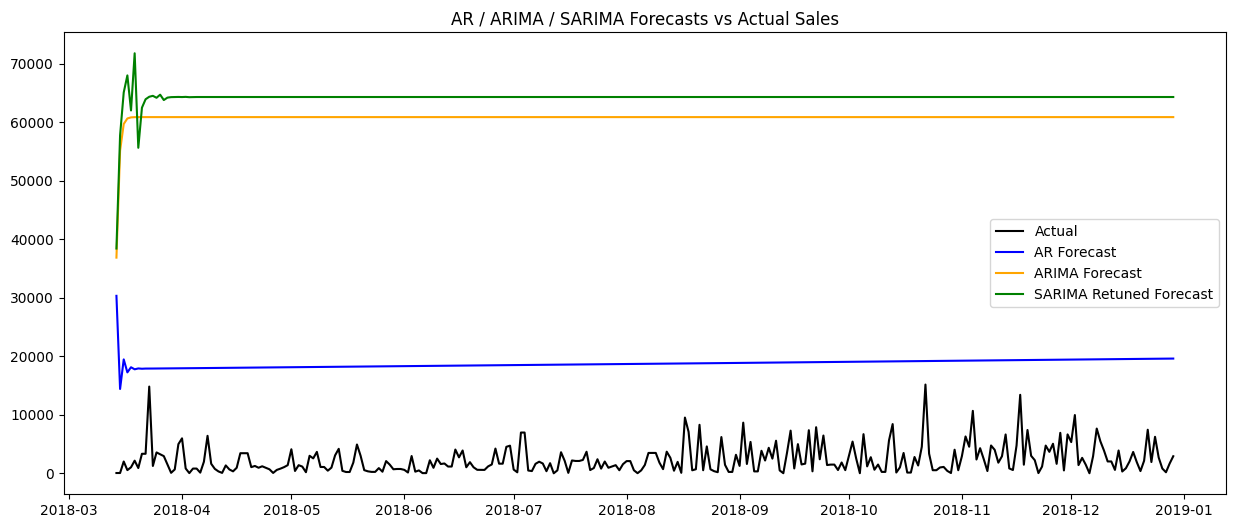

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(test_orig_aligned.index, test_orig_aligned, label="Actual", color="black")
plt.plot(test_orig_aligned.index, ar_forecast_orig, label="AR Forecast", color="blue")
plt.plot(test_orig_aligned.index, arima_forecast_orig, label="ARIMA Forecast", color="orange")
plt.plot(test_orig_aligned.index, sarima_forecast_orig_simple, label="SARIMA Retuned Forecast", color="green")
plt.title("AR / ARIMA / SARIMA Forecasts vs Actual Sales")
plt.legend()
plt.show()